In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statistics as st
import statsmodels.formula.api as smf
import statsmodels.api as sm

%matplotlib inline

# Data Exploration

In [ ]:
dataFile = pd.read_csv(df = pd.read_csv("https://raw.githubusercontent.com/HiltonZhou/Electricity-Demand-Regression/main/data/demand.csv"))
dataFile.head()

,Date,Hr_End,RT_Demand,Dry_Bulb
0,1/1/2025,1,1284.46,41
1,1/1/2025,2,1270.68,43
2,1/1/2025,3,1225.69,43
3,1/1/2025,4,1204.31,48
4,1/1/2025,5,1197.34,46


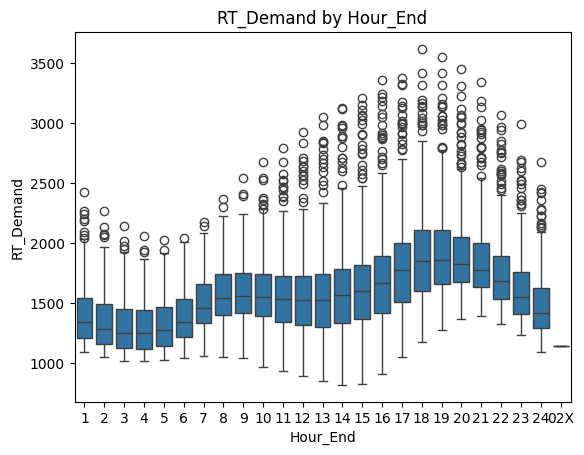

In [ ]:
# Create the comparative boxplot
sns.boxplot(x='Hr_End', y='RT_Demand', data= dataFile)

#title and labels
plt.title('RT_Demand by Hour_End')
plt.xlabel('Hour_End')
plt.ylabel('RT_Demand')

plt.show()

# Rt_Demand by Hour_End graph analysis :

Electrcity Demand is lowest in the early mornings approxnimately between 1 am - 6 am. This is because most people will be asleep at home.

From 6 am on, Electricity Demand starts increasing. Most people start waking up and business starts opening.

Electricty demand reach highest levels between 17-20 pm. Most people get off work and head home cooking dinner, using aplliances, and other things that use electricity.

From 20 pm on, Electricity demand drops as people are heading to sleep.

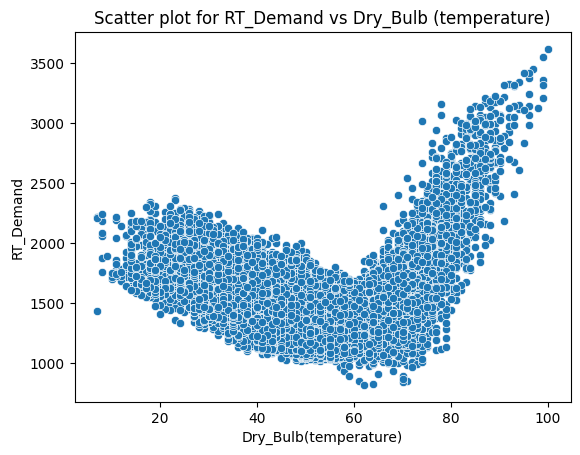

In [ ]:
# Create the comparative boxplot
sns.scatterplot(x='Dry_Bulb', y='RT_Demand', data= dataFile)

#title and labels
plt.title('Scatter plot for RT_Demand vs Dry_Bulb (temperature)')
plt.xlabel('Dry_Bulb(temperature)')
plt.ylabel('RT_Demand')

plt.show()

# Rt_Demand by Dry_Bulb graph analysis :

The data plot results in a U-shape

from 10 - 60 degrees(F) the Electrcity Demands trend decreases peaking at around 10 degrees.

from 60 - 100 degress(F) the Electricity Demand trend increases peaking at around 100 degrees.

This means that when temperatures are very cold and very hot, Electricity demand tend to be higher. The lowest avearage Electricity demand is around 60 degrees in the middle. However, it seems Electrcity demand is higher on hotter days than colder days.

# Multiple linear regression

In [ ]:
# Multiple Linear Regression
mlr = smf.ols(formula='RT_Demand ~ Hr_End + Dry_Bulb', data=dataFile)

res = mlr.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              RT_Demand   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     132.6
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:43:21   Log-Likelihood:                -62821.
No. Observations:                8760   AIC:                         1.257e+05
Df Residuals:                    8734   BIC:                         1.259e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1096.8669    315.514      3.476   

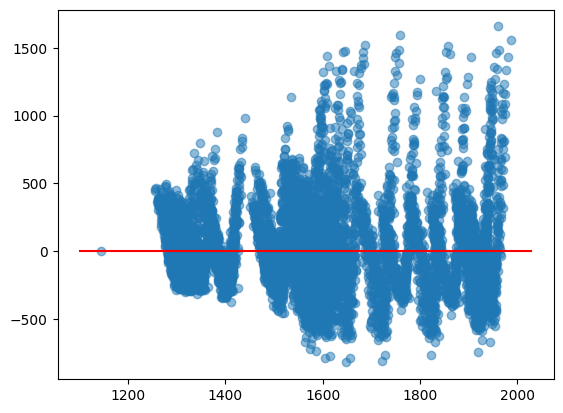

In [ ]:
# Residual plot
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, color='red')

plt.scatter(res.fittedvalues, res.resid, alpha=0.5)
abline(0,0)

# Polynomial Regression

In [ ]:
#Polynomial Regression Model

poly = smf.ols(formula='RT_Demand ~ Hr_End + Dry_Bulb +I(Dry_Bulb**2)' , data=dataFile)

res2 = poly.fit()

print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:              RT_Demand   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     793.1
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:43:22   Log-Likelihood:                -58920.
No. Observations:                8760   AIC:                         1.179e+05
Df Residuals:                    8733   BIC:                         1.181e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         2886.1779    202.773  

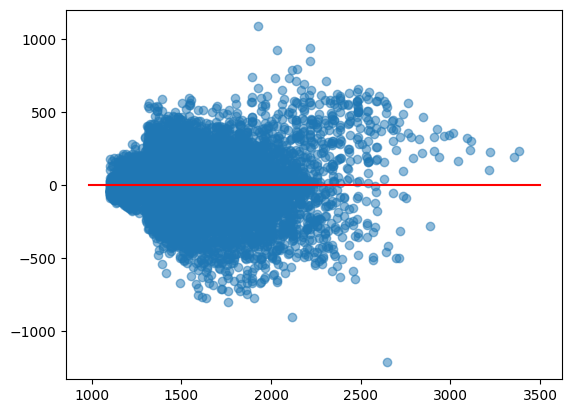

In [ ]:
plt.scatter(res2.fittedvalues, res2.resid, alpha=0.5)
abline(0,0)

# Model Justification and Best Model

Predictors: Hr_End and Dry_Bulb

Hr_end makes sense as a predictor because it has direct impact on Electrcity demand. It measures the the daily consumption pattern by showing the demand every hour.From the boxplot, it indicates the changes of Electrcity demand between sleep, work, and afterwork hours in a day.

Dry_Bulb makes sense as a predictor because we see evidence of temperature being correlated with Electricity Demand. From the scatterplot, we see that Electricity demand changes substantially as temperature changes because of need for heating and cooling etc.

**Best Model :**

From comparing the MLR model vs Polynomial Model, we can conclude that the **Polynomial regression model is the best model**.



MLR:

$$
RT\_Demand = \beta_0 + \beta_1(Hr\_End) + \beta_2(Dry\_Bulb) + \varepsilon
$$


Polynomial Regression:

$$
RT\_Demand = \beta_0 + \beta_1(Hr\_End) + \beta_2(Dry\_Bulb) + \beta_3(Dry\_Bulb^2) + \varepsilon
$$

From findings before based on the relationship of RT_Demand and Dry_Bulb, I found that the trend of the scatterplot resulted in a U-shape pattern. This indicates the relationship is quadratic. As a result, the original MLR model was updated by adding $Dry\_Bulb^2$ term, creating the polynomial regression model. After comparing the two models, the polynomial regression model was found to have an R^2 of 0.703 compared to MLR having a R^2 of 0.275. This means that polynomial regression model provided a better prediction since it was able to capture the quadratic like relationship between temperature and electricity demand.

# Future Improvement

Even though the polynomial regression model was an improvement to the multiple linear regression model, it still has limitations. The model only uses two predictors, Hr_end and Dry_Bulb even though there are many other factors that may influence electrcity demand. So leaving out other factors may harm the regression model in having a strong prediction therfore making the usage not very practical.

The polynomial regression model can be further polished or improve through:
  - comparing weekend vs weekday usage
  - other weather predictors such as humidity or wind speed etc.
  - more years of data before 2025

Furthermore we can have better prediction in the future by cleaning data better such as removing outlier points. As mentioned earlier, data spanning more years to include a larger data set to improve prediction.